In [1]:
!wget -nc https://zenodo.org/record/7041849/files/PapalexiSatija2021_eccite_RNA.h5ad
!wget -nc https://zenodo.org/record/7041849/files/PapalexiSatija2021_eccite_protein.h5ad
!pip install pyro-ppl graphviz seaborn anndata

File ‘PapalexiSatija2021_eccite_RNA.h5ad’ already there; not retrieving.

File ‘PapalexiSatija2021_eccite_protein.h5ad’ already there; not retrieving.


[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import multiprocessing

multiprocessing.cpu_count()

10

In [3]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd
import seaborn as sns
import pyro
import pyro.distributions as dist
from pyro.infer import (
    SVI,
    TraceEnum_ELBO,
    Trace_ELBO,
    TraceMeanField_ELBO,
    JitTraceEnum_ELBO,
    config_enumerate,
    infer_discrete,
)

from torch.utils.data import (
    Dataset,
    Sampler,
    DataLoader,
    WeightedRandomSampler,
    SubsetRandomSampler,
    BatchSampler,
)

from pyro.optim import Adam, ClippedAdam
from pyro.ops.indexing import Vindex

from pyro import poutine, render_model
from pyro.infer.autoguide import AutoNormal, AutoDelta, init_to_median, init_to_value
import sys
from tqdm import tqdm

if torch.cuda.is_available():
    print("Let's ride")
    device = "cuda"
    torch.set_float32_matmul_precision("high")
    # torch.set_default_device("cuda")
    smoke_test = False
else:
    device = "cpu"
    smoke_test = True
smoke_test = True


In [4]:
adata = ad.read_h5ad("PapalexiSatija2021_eccite_RNA.h5ad")
adata

AnnData object with n_obs × n_vars = 20729 × 18649
    obs: 'hto', 'guide_id', 'hto_barcode', 'gdo_barcode', 'perturbation', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo'
    var: 'ensembl_id', 'ncounts', 'ncells'

In [5]:
prot_adata = ad.read_h5ad("PapalexiSatija2021_eccite_protein.h5ad")
prot_adata.var_names = prot_adata.var_names + "_protein"

In [6]:
prot_df = prot_adata.to_df().join(prot_adata.obs)
prot_df


,CD86_protein,PDL1_protein,PDL2_protein,CD366_protein,hto,guide_id,hto_barcode,gdo_barcode,perturbation,tissue_type,...,cancer,disease,perturbation_type,celltype,organism,nperts,ngenes,ncounts,percent_mito,percent_ribo
AAACCTGAGCCAGAAC,118.0,522.0,94.0,67.0,rep1-tx,STAT2g2,AGGACCATCCAA,CTTCGTGTACGGTTGCACA,STAT2g2,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,801.0,0.0,0.0
AAACCTGAGTGGACGT,243.0,139.0,104.0,59.0,rep1-tx,CAV1g4,AGGACCATCCAA,GTCTACGTATTTGCCCCCA,CAV1g4,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,545.0,0.0,0.0
AAACCTGCATGAGCGA,99.0,109.0,56.0,80.0,rep1-tx,STAT1g2,AGGACCATCCAA,CATCCTTTGGTACAACATG,STAT1g2,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,344.0,0.0,0.0
AAACCTGTCTTGTCAT,110.0,334.0,48.0,47.0,rep1-tx,CD86g1,AGGACCATCCAA,ATTCCTTGGATTACAGCTG,CD86g1,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,539.0,0.0,0.0
AAACGGGAGAACAACT,303.0,593.0,77.0,80.0,rep1-tx,IRF7g2,AGGACCATCCAA,CCAGTACACCTTGCACTTG,IRF7g2,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,1053.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCACTTCC,98.0,151.0,135.0,14.0,rep3-tx,CMTM6g1,AGGACCATCCAA,CGTAGTGGGGCTGTACACC,CMTM6g1,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,398.0,0.0,0.0
TTTGTCAGTGACGGTA,1781.0,1117.0,89.0,55.0,rep4-tx,NTg4,TCGATAATGCGA,TGCGACGCTTAGCCTCCGT,control,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,0,4,3042.0,0.0,0.0
TTTGTCAGTTCCACAA,84.0,73.0,38.0,17.0,rep3-tx,ATF2g1,AGGACCATCCAA,TTCATTTCTCAGCAGGGTG,ATF2g1,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,212.0,0.0,0.0
TTTGTCATCACGCATA,18.0,135.0,37.0,68.0,rep3-tx,CAV1g2,AGGACCATCCAA,GTCATCGTTGAGGTGTTTA,CAV1g2,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,258.0,0.0,0.0


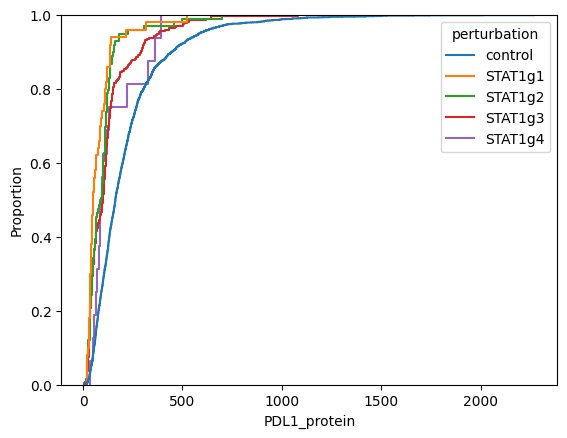

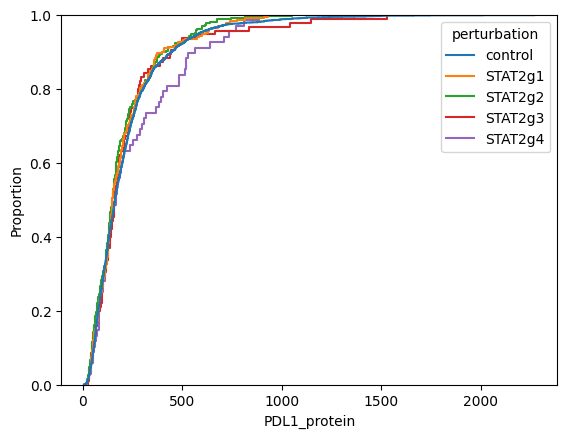

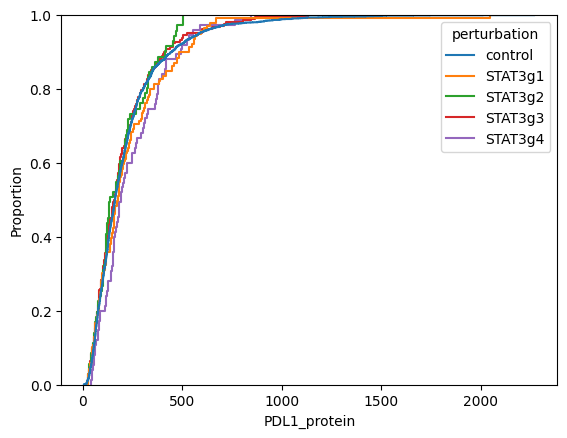

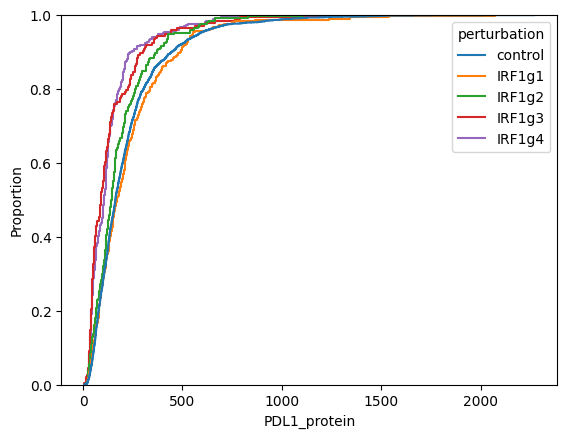

In [7]:
for plot_gene in ["STAT1", "STAT2", "STAT3", "IRF1"]:
    sns.ecdfplot(prot_df, hue="perturbation", x="PDL1_protein", hue_order=["control"]+[f"{plot_gene}g{i}" for i in range(1,5)])
    plt.show()

In [8]:
adata.obs

,hto,guide_id,hto_barcode,gdo_barcode,perturbation,tissue_type,cell_line,cancer,disease,perturbation_type,celltype,organism,nperts,ngenes,ncounts,percent_mito,percent_ribo
AAACCTGAGCCAGAAC,rep1-tx,STAT2g2,AGGACCATCCAA,CTTCGTGTACGGTTGCACA,STAT2g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3942,17207.0,2.295577,14.714942
AAACCTGAGTGGACGT,rep1-tx,CAV1g4,AGGACCATCCAA,GTCTACGTATTTGCCCCCA,CAV1g4,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2948,9506.0,4.512939,9.877972
AAACCTGCATGAGCGA,rep1-tx,STAT1g2,AGGACCATCCAA,CATCCTTTGGTACAACATG,STAT1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4258,15256.0,4.116413,13.227583
AAACCTGTCTTGTCAT,rep1-tx,CD86g1,AGGACCATCCAA,ATTCCTTGGATTACAGCTG,CD86g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,1780,5135.0,5.491723,21.888997
AAACGGGAGAACAACT,rep1-tx,IRF7g2,AGGACCATCCAA,CCAGTACACCTTGCACTTG,IRF7g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2671,9673.0,3.359868,13.263724
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCACTTCC,rep3-tx,CMTM6g1,AGGACCATCCAA,CGTAGTGGGGCTGTACACC,CMTM6g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4884,20863.0,5.469012,13.914586
TTTGTCAGTGACGGTA,rep4-tx,NTg4,TCGATAATGCGA,TGCGACGCTTAGCCTCCGT,control,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,0,3787,17553.0,2.159175,7.673902
TTTGTCAGTTCCACAA,rep3-tx,ATF2g1,AGGACCATCCAA,TTCATTTCTCAGCAGGGTG,ATF2g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4185,15106.0,2.661194,14.338673
TTTGTCATCACGCATA,rep3-tx,CAV1g2,AGGACCATCCAA,GTCATCGTTGAGGTGTTTA,CAV1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3204,11209.0,7.369078,10.036578


In [9]:
n_mito = adata[:, adata.var_names.str.startswith("MT-")].X.sum(axis=1).A1
n_rps = adata[:, adata.var_names.str.match("RPS[0-9]+")].X.sum(axis=1).A1
n_rpl = adata[:, adata.var_names.str.match("RPL[0-9]+")].X.sum(axis=1).A1
n_ribo = n_rps + n_rpl
n_total = adata.X.sum(axis=1).A1
# adata.obs
# plt.scatter(n_total, n_ribo, alpha=0.1)
# plt.scatter(n_total, n_mito, alpha=0.1)
# plt.scatter(n_ribo, n_mito, alpha=0.1)

In [10]:
adata.obs = adata.obs.assign(
    element=lambda x: x["perturbation"].str.replace("g[0-9]+$", "", regex=True)
)
adata.obs["element"]

AAACCTGAGCCAGAAC      STAT2
AAACCTGAGTGGACGT       CAV1
AAACCTGCATGAGCGA      STAT1
AAACCTGTCTTGTCAT       CD86
AAACGGGAGAACAACT       IRF7
                     ...   
TTTGTCAGTCACTTCC      CMTM6
TTTGTCAGTGACGGTA    control
TTTGTCAGTTCCACAA       ATF2
TTTGTCATCACGCATA       CAV1
TTTGTCATCTGTACGA      STAT3
Name: element, Length: 20729, dtype: object

In [11]:
# pick a subset of random genes including 3 known ones
# stat_target_genes = ["STAT1", "STAT2", "IRF1"]

# pick a subset of 50 genes including all perturbed ones

if smoke_test:
    n_genes_subset = 50
    target_genes = [e for e in adata.obs["element"].unique() if e != "control"]
    # target_genes += prot_adata.var_names.tolist()
    other_genes = [gene for gene in adata.var_names if gene not in target_genes]
    selected_genes = target_genes + other_genes[: n_genes_subset - len(target_genes)]
    # selected_genes = stat_target_genes + list(
    #     np.random.choice(other_genes, size=n_genes_subset - len(stat_target_genes))
    # )

    # selected_guides = [f"STAT1g{i}" for i in range(1, 5)] + ["control"]
    # guide_filter = adata.obs["perturbation"].isin(selected_guides)
    # adata_subset = adata[guide_filter, :][:, selected_genes]
    adata_subset = adata[:, selected_genes]

else:
    min_counts = 100 # min no. of cells with at least 1 count
    selected_genes = ((adata.X>0).sum(axis=0)) > min_counts
    adata_subset = adata[:, selected_genes]
adata_subset

View of AnnData object with n_obs × n_vars = 20729 × 50
    obs: 'hto', 'guide_id', 'hto_barcode', 'gdo_barcode', 'perturbation', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'element'
    var: 'ensembl_id', 'ncounts', 'ncells'

In [12]:
adata_subset.var_names

Index(['STAT2', 'CAV1', 'STAT1', 'CD86', 'IRF7', 'ATF2', 'STAT3', 'JAK2',
       'NFKBIA', 'SMAD4', 'STAT5A', 'CMTM6', 'IFNGR1', 'UBE2L6', 'PDCD1LG2',
       'CUL3', 'BRD4', 'MARCH8', 'IRF1', 'POU2F2', 'ETV7', 'IFNGR2',
       'TNFRSF14', 'SPI1', 'MYC', 'AL627309.1', 'AP006222.2', 'RP4-669L17.10',
       'RP11-206L10.3', 'RP11-206L10.2', 'RP11-206L10.9', 'LINC00115',
       'FAM41C', 'SAMD11', 'NOC2L', 'KLHL17', 'PLEKHN1', 'HES4', 'ISG15',
       'AGRN', 'RP11-54O7.18', 'C1orf159', 'TNFRSF18', 'TNFRSF4', 'SDF4',
       'B3GALT6', 'FAM132A', 'RP5-902P8.12', 'UBE2J2', 'SCNN1D'],
      dtype='object', name='gene_symbol')

In [13]:
# from siphon.module import train
import mudata as md
grna_observed = pd.get_dummies(adata_subset.obs["guide_id"]).astype(int)

In [14]:
guide_by_element = (
    pd.crosstab(adata_subset.obs["guide_id"], adata_subset.obs["element"])
    .reindex(index=grna_observed.columns)
    > 0
).astype(int)

guide_by_element = guide_by_element.iloc[:,:-1] # remove control
guide_by_element

element,ATF2,BRD4,CAV1,CD86,CMTM6,CUL3,ETV7,IFNGR1,IFNGR2,IRF1,...,PDCD1LG2,POU2F2,SMAD4,SPI1,STAT1,STAT2,STAT3,STAT5A,TNFRSF14,UBE2L6
ATF2g1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ATF2g2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ATF2g3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ATF2g4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BRD4g1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TNFRSF14g4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
UBE2L6g1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
UBE2L6g2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
UBE2L6g3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [15]:
n_elements = guide_by_element.shape[1]
gene_by_element = (
    pd.DataFrame(np.eye(n_elements), index=guide_by_element.columns, columns=guide_by_element.columns)
    .reindex(index=adata_subset.var_names)
    .fillna(0)
)
adata_subset.varm["element_targets"] = gene_by_element
adata_subset.varm["element_targets"]

/var/folders/w9/llll0v7j02zdytwd43sshysm0000gp/T/ipykernel_93791/1485371578.py:7: ImplicitModificationWarning: Setting element `.varm['element_targets']` of view, initializing view as actual.
  adata_subset.varm["element_targets"] = gene_by_element


element,ATF2,BRD4,CAV1,CD86,CMTM6,CUL3,ETV7,IFNGR1,IFNGR2,IRF1,...,PDCD1LG2,POU2F2,SMAD4,SPI1,STAT1,STAT2,STAT3,STAT5A,TNFRSF14,UBE2L6
gene_symbol,,,,,,,,,,,,,,,,,,,,,
STAT2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
CAV1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
STAT1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
CD86,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
IRF7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ATF2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
STAT3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
JAK2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NFKBIA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
gdata = ad.AnnData(grna_observed, varm={"guide_targets": guide_by_element})
mdata = md.MuData({"rna":adata_subset, "grna":gdata})
mdata

MuData object with n_obs × n_vars = 20729 × 157
  2 modalities
    rna:	20729 x 50
      obs:	'hto', 'guide_id', 'hto_barcode', 'gdo_barcode', 'perturbation', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'element'
      var:	'ensembl_id', 'ncounts', 'ncells'
      varm:	'element_targets'
    grna:	20729 x 107
      varm:	'guide_targets'

In [17]:
mdata["rna"].obs

,hto,guide_id,hto_barcode,gdo_barcode,perturbation,tissue_type,cell_line,cancer,disease,perturbation_type,celltype,organism,nperts,ngenes,ncounts,percent_mito,percent_ribo,element
AAACCTGAGCCAGAAC,rep1-tx,STAT2g2,AGGACCATCCAA,CTTCGTGTACGGTTGCACA,STAT2g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3942,17207.0,2.295577,14.714942,STAT2
AAACCTGAGTGGACGT,rep1-tx,CAV1g4,AGGACCATCCAA,GTCTACGTATTTGCCCCCA,CAV1g4,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2948,9506.0,4.512939,9.877972,CAV1
AAACCTGCATGAGCGA,rep1-tx,STAT1g2,AGGACCATCCAA,CATCCTTTGGTACAACATG,STAT1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4258,15256.0,4.116413,13.227583,STAT1
AAACCTGTCTTGTCAT,rep1-tx,CD86g1,AGGACCATCCAA,ATTCCTTGGATTACAGCTG,CD86g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,1780,5135.0,5.491723,21.888997,CD86
AAACGGGAGAACAACT,rep1-tx,IRF7g2,AGGACCATCCAA,CCAGTACACCTTGCACTTG,IRF7g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2671,9673.0,3.359868,13.263724,IRF7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCACTTCC,rep3-tx,CMTM6g1,AGGACCATCCAA,CGTAGTGGGGCTGTACACC,CMTM6g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4884,20863.0,5.469012,13.914586,CMTM6
TTTGTCAGTGACGGTA,rep4-tx,NTg4,TCGATAATGCGA,TGCGACGCTTAGCCTCCGT,control,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,0,3787,17553.0,2.159175,7.673902,control
TTTGTCAGTTCCACAA,rep3-tx,ATF2g1,AGGACCATCCAA,TTCATTTCTCAGCAGGGTG,ATF2g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4185,15106.0,2.661194,14.338673,ATF2
TTTGTCATCACGCATA,rep3-tx,CAV1g2,AGGACCATCCAA,GTCATCGTTGAGGTGTTTA,CAV1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3204,11209.0,7.369078,10.036578,CAV1


In [18]:
import perturbo
perturbo.PERTURBO.setup_mudata(
    mdata,
    batch_key="hto",
    library_size_key="ncounts",
    continuous_covariates_keys=["percent_mito", "percent_ribo"],
    guide_by_element_key="guide_targets",
    gene_by_element_key="element_targets",
    modalities={
        "rna_layer": "rna",
        "perturbation_layer": "grna",
    },
)

model = perturbo.PERTURBO(mdata, likelihood="nb", efficiency_mode="mixture", n_factors=5, n_pert_factors=20)
# model = perturbo.PERTURBO(mdata, likelihood="nb", efficiency_mode="mixture", n_factors=5, n_pert_factors=20)
# model = perturbo.PERTURBO(mdata, likelihood="nb", efficiency_mode="scaled", n_factors=5, n_pert_factors=10)

model.view_anndata_setup()


/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


INFO     Using column names from columns of adata.varm['guide_targets']                                            


<frozen abc>:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

<frozen abc>:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/data/fields/_layer_field.py:101: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self

Anndata setup with scvi-tools version 1.0.4.

Setup via `PERTURBO.setup_anndata` with arguments:

...

        Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃    Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch         │   5   │
│         n_cells         │ 20729 │
│ n_extra_continuous_covs │   2   │
│  n_gene_summary_stats   │   1   │
│     n_perturbations     │  107  │
│   n_targeted_elements   │  25   │
│         n_vars          │  50   │
└─────────────────────────┴───────┘

                                 Data Registry                                  
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Registry Key      ┃                 scvi-tools Location                  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X           │                  adata.mod['rna'].X                  │
│         batch         │         adata.mod['rna'].obs['_scvi_batch']          │
│ extra_continuous_covs │ adata.mod['rna'].obsm['_scvi_extra_continuous_covs'] │
│  gene_summary_stats   │  adata.mod['rna'].varm['_scvi_gene_summary_stats']   │
│         ind_x         │            adata.mod['rna'].obs['_ind_x']            │
│     perturbations     │                 adata.mod['grna'].X                  │
│      size_factor      │         adata.mod['rna'].obs['_size_factor']         │
│   targeted_elements   │       adata.mod['grna'].varm['guide_targets']        │
└───────────────────────┴──────────────────────────────────────────────────────┘

                 batch State Registry                  
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Source Location  ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['hto'] │  rep1-tx   │          0          │
│                  │ rep2-ctrl  │          1          │
│                  │  rep2-tx   │          2          │
│                  │  rep3-tx   │          3          │
│                  │  rep4-tx   │          4          │
└──────────────────┴────────────┴─────────────────────┘

 gene_summary_stats State  
         Registry          
┏━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location     ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.var['_gene_mean'] │
└─────────────────────────┘

 extra_continuous_covs State 
          Registry           
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['percent_mito'] │
│ adata.obs['percent_ribo'] │
└───────────────────────────┘

In [19]:
model.train(
    200,
    lr=0.01,
    batch_size=512,
    # callbacks=[checkpoint_callback],
    # enable_checkpointing=True,
    early_stopping=True,
    early_stopping_patience=10,
    early_stopping_min_delta=1e-2,
    early_stopping_monitor="elbo_train",
)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/lightning/pytorch/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/lightning/pytorch/trainer/configuration_validator.py:69: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")


Epoch 120/200:  60%|██████    | 120/200 [01:22<00:54,  1.46it/s, v_num=1, elbo_train=9.96e+5]
Monitored metric elbo_train did not improve in the last 10 records. Best score: 995387.500. Signaling Trainer to stop.


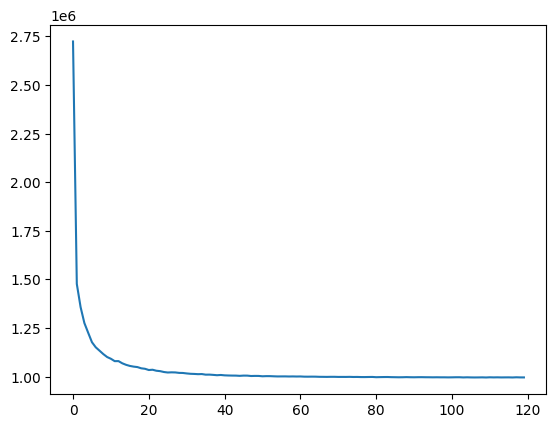

In [20]:
plt.plot(model.history["elbo_train"])

In [21]:
model.module.guide.median().keys()

dict_keys(['guide_efficacy', 'log_gene_mean', 'log_gene_dispersion', 'batch_effect', 'cont_covariate_effect', 'element_effects'])

In [22]:
import scanpy as sc
# pyro.get_param_store["cell_factors"].shape
if "cell_factors" in model.module.guide.median():
    cell_factors = model.module.guide.median()["cell_factors"].squeeze().T.numpy()
    cell_factors = pyro.get_param_store()["AutoGuideList.1.cell_factors"].detach().squeeze().T.numpy()
    mdata["rna"].obsm["X_ppca"] = cell_factors
    sc.pl.embedding(mdata["rna"], basis="X_ppca", color="hto")

In [23]:
if "cell_loadings" in model.module.guide.median():
    loadings_df = pd.DataFrame(model.module.guide.median()["cell_loadings"].squeeze(), columns=mdata["rna"].var_names)
    loadings_df

In [24]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)


AutoGuideList.0.locs.guide_efficacy torch.Size([107, 1])
AutoGuideList.0.scales.guide_efficacy torch.Size([107, 1])
AutoGuideList.0.locs.log_gene_mean torch.Size([50])
AutoGuideList.0.scales.log_gene_mean torch.Size([50])
AutoGuideList.0.locs.log_gene_dispersion torch.Size([50])
AutoGuideList.0.scales.log_gene_dispersion torch.Size([50])
AutoGuideList.0.locs.batch_effect torch.Size([5, 50])
AutoGuideList.0.scales.batch_effect torch.Size([5, 50])
AutoGuideList.0.locs.cont_covariate_effect torch.Size([3, 50])
AutoGuideList.0.scales.cont_covariate_effect torch.Size([3, 50])
perturbo$$$_guide.0.locs.guide_efficacy_unconstrained torch.Size([107, 1])
perturbo$$$_guide.0.locs.log_gene_mean_unconstrained torch.Size([50])
perturbo$$$_guide.0.locs.log_gene_dispersion_unconstrained torch.Size([50])
perturbo$$$_guide.0.locs.batch_effect_unconstrained torch.Size([5, 50])
perturbo$$$_guide.0.locs.cont_covariate_effect_unconstrained torch.Size([3, 50])
perturbo$$$_guide.0.scales.guide_efficacy_uncons

In [25]:
# plt.scatter(siphon_model.dataset.size_factor, siphon_model.guide.median()["size_factor_fit"], alpha=0.01)

In [26]:
# plt.plot(losses)

In [27]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)

AutoGuideList.0.locs.guide_efficacy torch.Size([107, 1])
AutoGuideList.0.scales.guide_efficacy torch.Size([107, 1])
AutoGuideList.0.locs.log_gene_mean torch.Size([50])
AutoGuideList.0.scales.log_gene_mean torch.Size([50])
AutoGuideList.0.locs.log_gene_dispersion torch.Size([50])
AutoGuideList.0.scales.log_gene_dispersion torch.Size([50])
AutoGuideList.0.locs.batch_effect torch.Size([5, 50])
AutoGuideList.0.scales.batch_effect torch.Size([5, 50])
AutoGuideList.0.locs.cont_covariate_effect torch.Size([3, 50])
AutoGuideList.0.scales.cont_covariate_effect torch.Size([3, 50])
perturbo$$$_guide.0.locs.guide_efficacy_unconstrained torch.Size([107, 1])
perturbo$$$_guide.0.locs.log_gene_mean_unconstrained torch.Size([50])
perturbo$$$_guide.0.locs.log_gene_dispersion_unconstrained torch.Size([50])
perturbo$$$_guide.0.locs.batch_effect_unconstrained torch.Size([5, 50])
perturbo$$$_guide.0.locs.cont_covariate_effect_unconstrained torch.Size([3, 50])
perturbo$$$_guide.0.scales.guide_efficacy_uncons

In [28]:
guide=model.module.guide
guides = mdata["grna"].var_names
elements = guide_by_element.index
guide.median().keys()

dict_keys(['guide_efficacy', 'log_gene_mean', 'log_gene_dispersion', 'batch_effect', 'cont_covariate_effect', 'element_effects'])

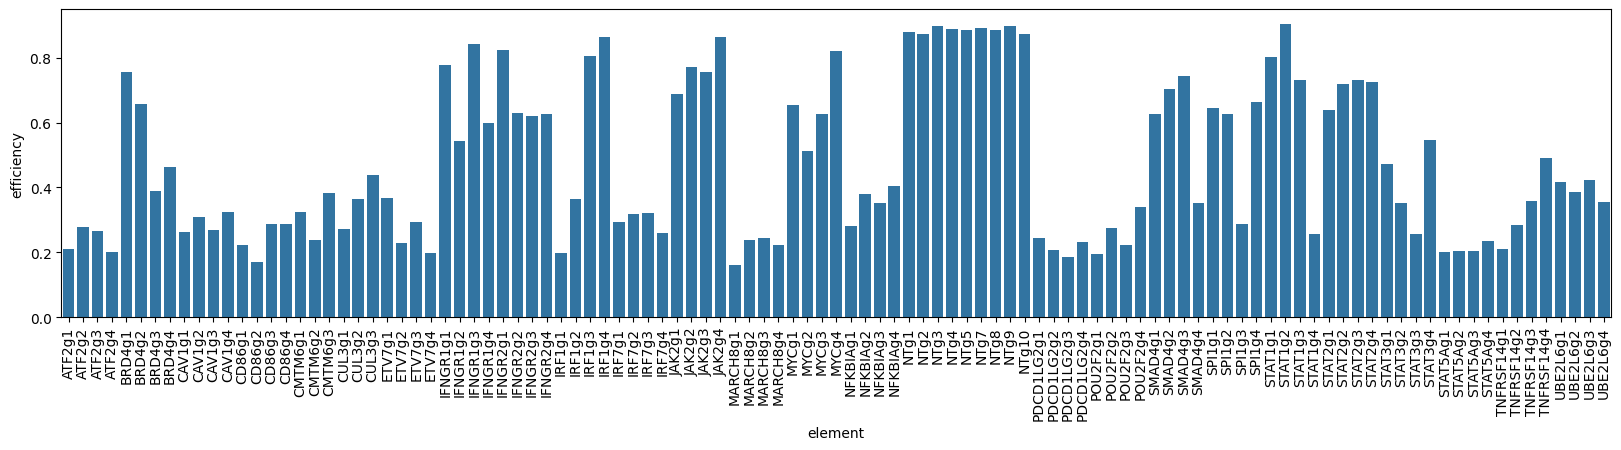

In [29]:
guides = guide_by_element.index
elements = guide_by_element.columns
plt.figure(figsize=(20, 4))
if "guide_efficacy" in guide.median():
    element_efficiency = pd.DataFrame(
        guide.median()["guide_efficacy"].detach().cpu(),
        index=guides,
        columns=["efficiency"],
    ).reset_index(names="element")
    element_efficiency
    sns.barplot(element_efficiency, x="element", y="efficiency")
    plt.xticks(rotation=90)

array([[<Axes: title={'center': 'efficiency'}>]], dtype=object)

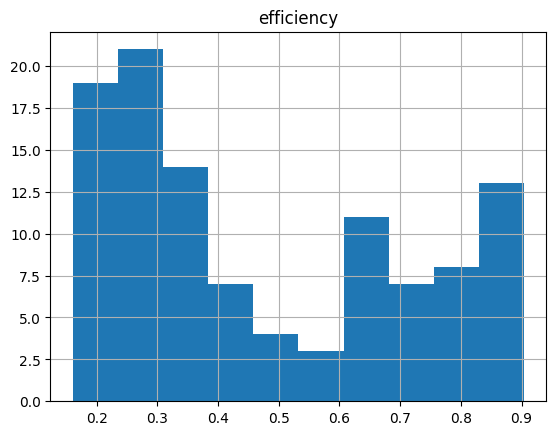

In [30]:
median_efficiency = pd.DataFrame(
    guide.median()["guide_efficacy"].detach().cpu(),
    index=guides,
    columns=["efficiency"],
).assign(
    guide=lambda x: x.index,
    element=lambda x: x.index.str.replace("g[0-9]+$", "", regex=True),
)
median_efficiency.hist("efficiency")

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25],
 [Text(0, 0, 'ATF2'),
  Text(1, 0, 'BRD4'),
  Text(2, 0, 'CAV1'),
  Text(3, 0, 'CD86'),
  Text(4, 0, 'CMTM6'),
  Text(5, 0, 'CUL3'),
  Text(6, 0, 'ETV7'),
  Text(7, 0, 'IFNGR1'),
  Text(8, 0, 'IFNGR2'),
  Text(9, 0, 'IRF1'),
  Text(10, 0, 'IRF7'),
  Text(11, 0, 'JAK2'),
  Text(12, 0, 'MARCH8'),
  Text(13, 0, 'MYC'),
  Text(14, 0, 'NFKBIA'),
  Text(15, 0, 'NT'),
  Text(16, 0, 'PDCD1LG2'),
  Text(17, 0, 'POU2F2'),
  Text(18, 0, 'SMAD4'),
  Text(19, 0, 'SPI1'),
  Text(20, 0, 'STAT1'),
  Text(21, 0, 'STAT2'),
  Text(22, 0, 'STAT3'),
  Text(23, 0, 'STAT5A'),
  Text(24, 0, 'TNFRSF14'),
  Text(25, 0, 'UBE2L6')])

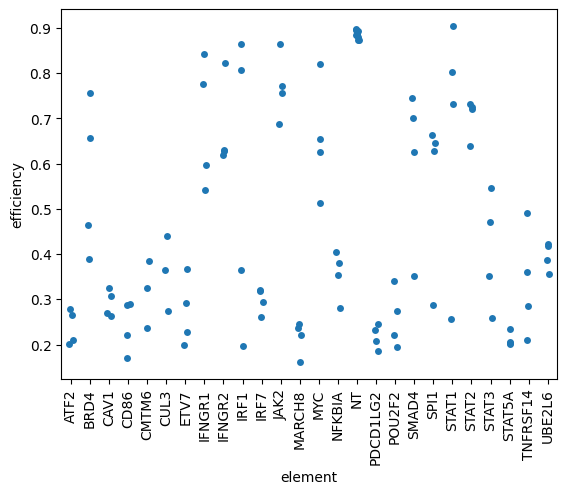

In [31]:
sns.stripplot(median_efficiency, x="element", y="efficiency")
plt.xticks(rotation=90)

In [32]:
effects_df_long = model.get_element_effects()
effects_df_long

,element,gene,loc,scale,z_value,q_value
461,JAK2,IRF1,-2.194098,0.034719,-63.195103,0.000000e+00
457,IFNGR1,IRF1,-2.069204,0.034032,-60.801136,0.000000e+00
69,STAT1,STAT1,-2.943551,0.059750,-49.264240,0.000000e+00
57,IFNGR1,STAT1,-1.033628,0.021504,-48.066681,0.000000e+00
333,IFNGR2,UBE2L6,-1.120084,0.025073,-44.672340,0.000000e+00
...,...,...,...,...,...,...
311,JAK2,IFNGR1,0.548050,0.042156,13.000548,1.214695e-38
958,IFNGR2,ISG15,0.406070,0.030013,13.529718,1.044227e-41
308,IFNGR2,IFNGR1,0.482138,0.034706,13.891965,7.086409e-44
957,IFNGR1,ISG15,0.494504,0.034911,14.164864,1.511605e-45


In [57]:
effects_df = effects_df_long.pivot_table(values="loc", index="element", columns="gene").fillna(0)
effects_df

gene,AGRN,AL627309.1,AP006222.2,ATF2,B3GALT6,BRD4,C1orf159,CAV1,CD86,CMTM6,...,SPI1,STAT1,STAT2,STAT3,STAT5A,TNFRSF14,TNFRSF18,TNFRSF4,UBE2J2,UBE2L6
element,,,,,,,,,,,,,,,,,,,,,
ATF2,-0.090128,-0.636569,0.175909,0.013476,0.300290,-0.083093,-0.007428,0.762910,-0.739339,-0.174288,...,-0.247102,-0.183047,-0.329589,-0.432916,-0.516513,-0.314860,-0.425829,-0.805941,-0.095786,-0.153148
BRD4,-0.360334,-0.583336,-0.625583,-0.117212,-0.200559,-0.825891,-0.347607,-0.818189,-1.905526,-0.107127,...,-0.424455,0.024735,-0.229991,-0.147857,-1.149064,-0.074158,-0.331198,-1.127624,-0.396308,0.059273
CAV1,-0.586300,-0.987125,0.239947,0.001156,0.333341,-0.242674,-0.842078,-0.972654,-0.745454,-0.070405,...,-0.208558,-0.109297,-0.192496,-0.317194,-0.758317,-0.241812,0.189161,-1.133512,-0.199770,-0.173601
CD86,-0.385138,0.034857,0.127265,0.112169,0.010546,-0.183980,-0.166387,-0.051137,-1.529437,-0.033535,...,-0.236058,-0.203738,-0.360881,-0.328611,-0.265294,-0.250440,-0.743575,-1.162024,0.039026,-0.164834
CMTM6,-0.055798,-0.159905,0.509037,0.079647,0.254977,-0.083181,0.044920,0.784030,-0.765610,-0.913849,...,-0.221030,-0.346168,-0.326945,-0.352778,-0.835663,-0.113296,-0.300052,-1.149921,-0.286369,-0.235193
CUL3,-0.138815,-0.875082,-0.138500,-0.626574,-0.379117,-0.185269,-0.453493,3.192291,-0.619040,-0.279666,...,-0.023304,-0.558961,-0.657680,-0.350523,-0.333196,-0.264493,-0.094882,-0.056130,-0.122807,-0.274435
ETV7,-0.179017,-0.636018,0.123885,0.255960,0.238315,0.115932,0.253162,0.165753,-1.508718,-0.191106,...,-0.327825,-0.124126,-0.322362,-0.146104,-0.493579,-0.310522,-0.533820,-0.789176,0.071575,-0.142239
IFNGR1,0.817262,-0.751476,0.606436,0.216369,0.249144,0.012384,-0.126346,-0.831055,0.088979,-0.098582,...,0.016232,-1.033628,-0.648369,-0.520576,-0.064987,-1.268540,-0.415167,0.084030,0.173181,-1.043022
IFNGR2,0.699842,-1.110143,0.381784,0.222061,0.283444,0.077819,-0.319055,-0.024370,-0.279766,-0.070003,...,0.007783,-1.104614,-0.751763,-0.453655,-0.269375,-1.240987,-0.099291,0.246373,0.119118,-1.120084


In [52]:
cis_effects = effects_df_long.query("element==gene")
cis_effects

,element,gene,loc,scale,z_value,q_value
69,STAT1,STAT1,-2.943551,0.059750,-49.264240,0.000000e+00
186,JAK2,JAK2,-2.292378,0.069614,-32.929863,8.217233e-238
533,IFNGR2,IFNGR2,-0.561100,0.026863,-20.887381,6.974157e-97
459,IRF1,IRF1,-0.358018,0.024352,-14.701777,6.278975e-49
20,STAT2,STAT2,-1.030969,0.071628,-14.393332,5.698287e-47
573,TNFRSF14,TNFRSF14,-1.291149,0.107199,-12.044415,2.075420e-33
110,IRF7,IRF7,-1.061624,0.092167,-11.518462,1.064946e-30
214,NFKBIA,NFKBIA,-1.392473,0.128776,-10.813114,2.983658e-27
279,CMTM6,CMTM6,-0.913849,0.084925,-10.760674,5.278245e-27
171,STAT3,STAT3,-0.747704,0.079016,-9.462729,3.000075e-21


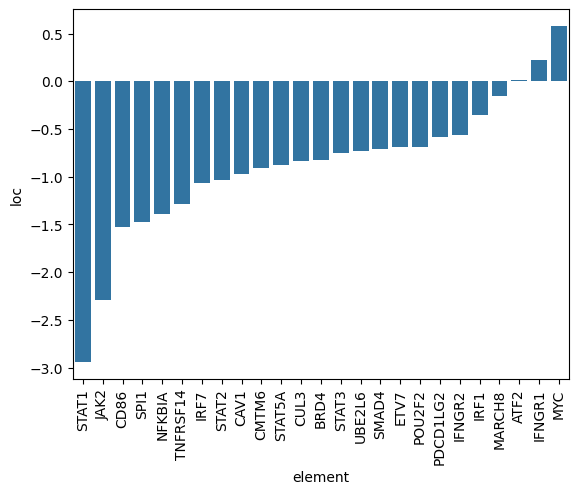

In [53]:
# median_cis_effect = guide.median()["cis_effect"].detach().cpu()
# low_cis_effect, high_cis_effect = (
    # guide.quantiles([0.159, 0.841])["cis_effect"].detach().cpu()
# )
# sigma_cis_effect = high_cis_effect - median_cis_effect
# z_score_cis_effect = median_cis_effect / sigma_cis_effect

sns.barplot(cis_effects.sort_values("loc"), x="element", y="loc")
plt.xticks(rotation=90)
plt.show()

# sns.barplot(x=elements, y=z_score_cis_effect.squeeze())

# plt.xticks(rotation=90)
# plt.show()

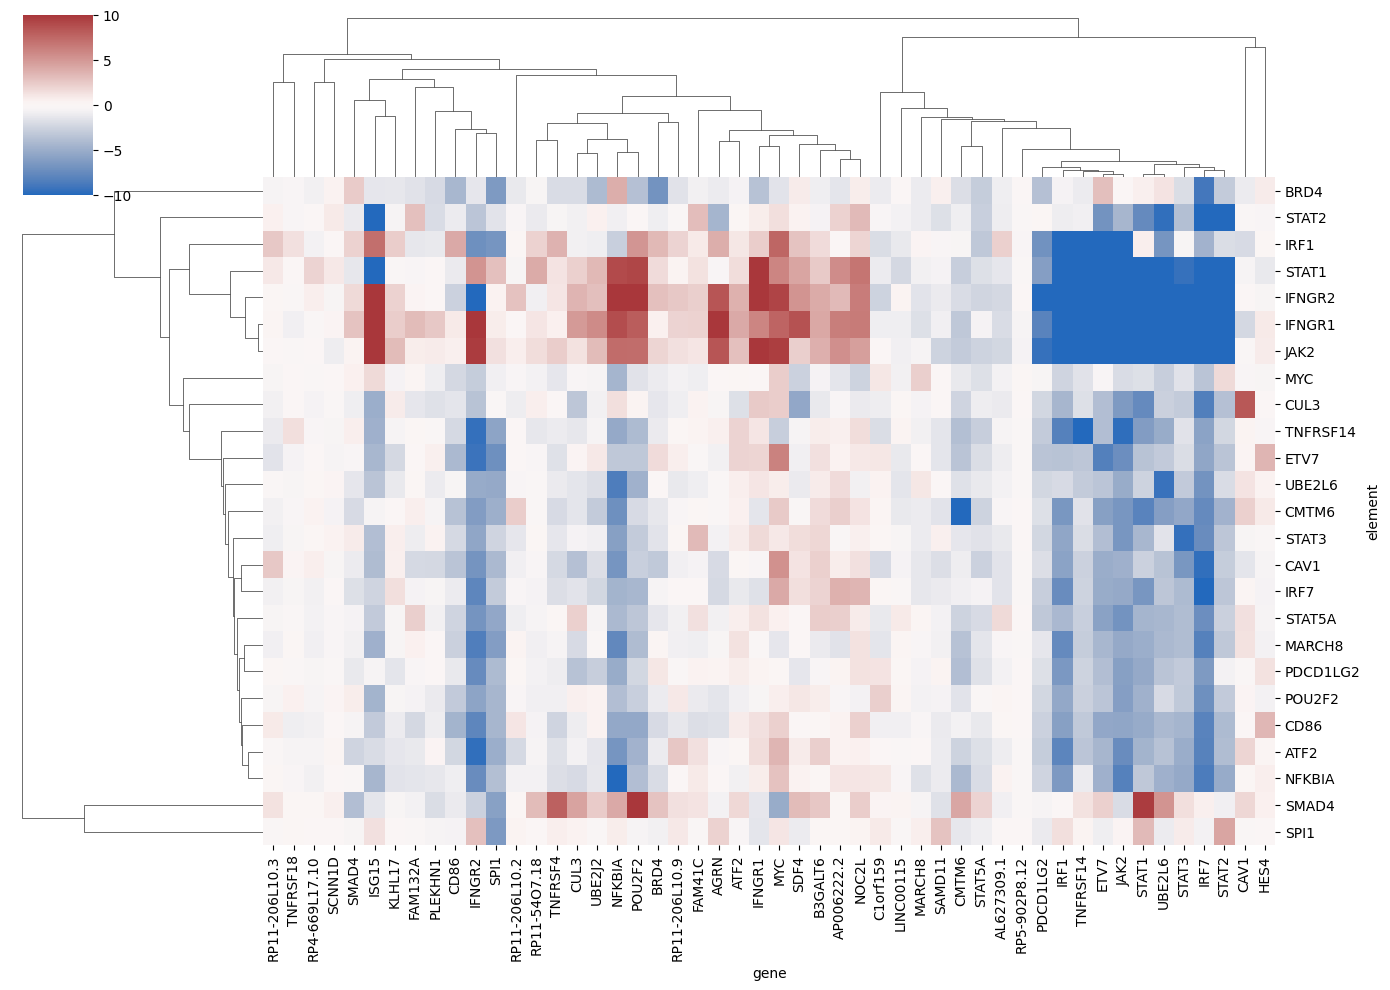

In [56]:

sns.clustermap(
    effects_df,
    center=0,
    vmax=1,
    vmin=-1,
    cmap="vlag",
    metric="cosine",
    figsize=(14, 10),
    # col_cluster=False,
    # row_cluster=False
)

In [48]:
pert_factors = pd.DataFrame(
    model.module.guide.median()["pert_factors"].squeeze(),
    columns=elements,
)
sns.clustermap(pert_factors, cmap="vlag", figsize=(8, 6), row_cluster=False, center=0)
pert_factors



KeyError: 'pert_factors'

In [50]:
pert_loadings = pd.DataFrame(
    model.module.guide.median()["pert_loadings"].squeeze(),
    columns=mdata["rna"].var_names,
)

pert_loadings


KeyError: 'pert_loadings'

In [49]:
top_genes = (pert_loadings**2).max().nlargest(100).index
pert_loadings_subset = pert_loadings.loc[:, top_genes]
sns.clustermap(pert_loadings_subset, cmap="vlag", row_cluster=False, figsize=(14, 6), center=0)


NameError: name 'pert_loadings' is not defined

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


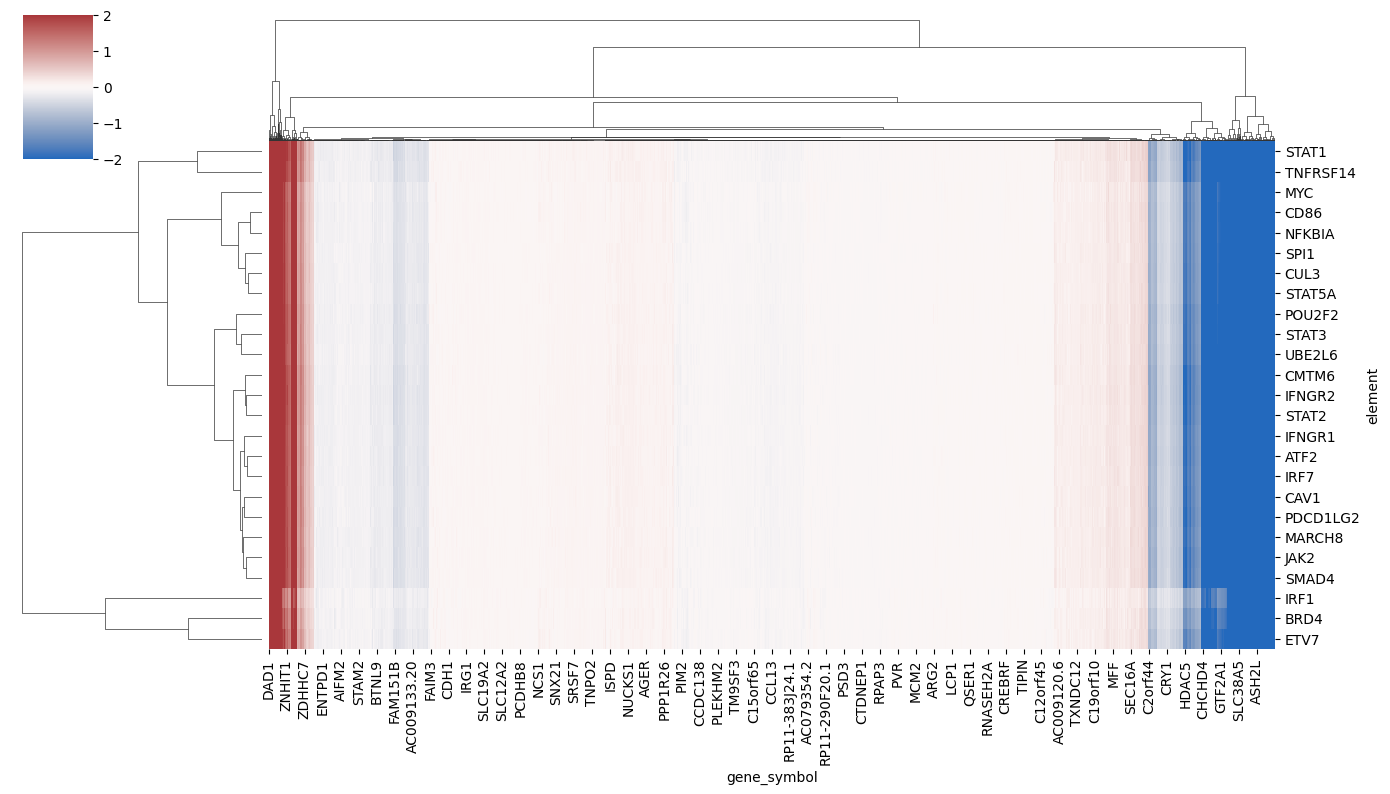

In [41]:
reconstructed_effects = pd.DataFrame(
    pert_factors.values.T @ pert_loadings.values,
    index=elements,
    columns=mdata["rna"].var_names,
)
sns.clustermap(reconstructed_effects, center=0, cmap="vlag", figsize=(14, 8),vmin=-2, vmax=2)

In [42]:
# effects_df = effects
# sns.stripplot(guide.median()["effect"])
# # print(n_guides)
# from numpy import median

# median_effect = guide.median()["trans_effect"].detach().cpu()
# low_effect, high_effect = guide.quantiles([0.159, 0.841])["trans_effect"].detach().cpu()
# sigma_effect = high_effect - low_effect
# z_score_effect = median_effect / sigma_effect

# effects_df = pd.DataFrame(
#     effects,
#     # z_score_effect,
#     columns=adata_subset.var_names,
#     index=elements,
# )
# effects_df

# effects_df = pd.DataFrame(
#     median_effect,
#     columns=adata_subset.var_names,
#     index=list(element_mapping.keys())[:n_elements],
# )
# effects_df

In [43]:

plot_genes = [g for g in list(cis_effects["element"]) if g != "control"]
plot_genes

['IFNGR2',
 'SMAD4',
 'ETV7',
 'STAT5A',
 'CAV1',
 'STAT3',
 'NFKBIA',
 'BRD4',
 'MYC',
 'CUL3',
 'POU2F2',
 'TNFRSF14',
 'MARCH8',
 'IRF1',
 'UBE2L6',
 'CD86',
 'IFNGR1',
 'PDCD1LG2',
 'IRF7',
 'JAK2',
 'SPI1',
 'STAT1',
 'ATF2',
 'STAT2',
 'CMTM6']

In [44]:
# effect_variance = effects_df.var(axis=0)
effect_variance = effects_df_long.groupby("gene")["loc"].var()
# effect_variance = (effects_df.abs() > 5).sum(axis=0)
# effect_variance = (effects_df.loc[["STAT3", "STAT5A", "CAV1", "CD86"]].abs()).sum(
#     axis=0
# )
hvgs = effect_variance.nlargest(50).index.tolist()
hvgs
# effects_df[effects_df["gene"].isin(hvgs)]


['ATF2',
 'BRD4',
 'CAV1',
 'CD86',
 'CMTM6',
 'CUL3',
 'ETV7',
 'IFNGR1',
 'IFNGR2',
 'IRF1',
 'IRF7',
 'JAK2',
 'MARCH8',
 'MYC',
 'NFKBIA',
 'PDCD1LG2',
 'POU2F2',
 'SMAD4',
 'SPI1',
 'STAT1',
 'STAT2',
 'STAT3',
 'STAT5A',
 'TNFRSF14',
 'UBE2L6']

In [45]:
# plt.scatter(guide.median()["gene_mean"].cpu().log(), guide.median()["dispersion"].cpu().log(), alpha=0.1)

In [46]:
if not smoke_test:
    pyro.get_param_store().save("params.save")

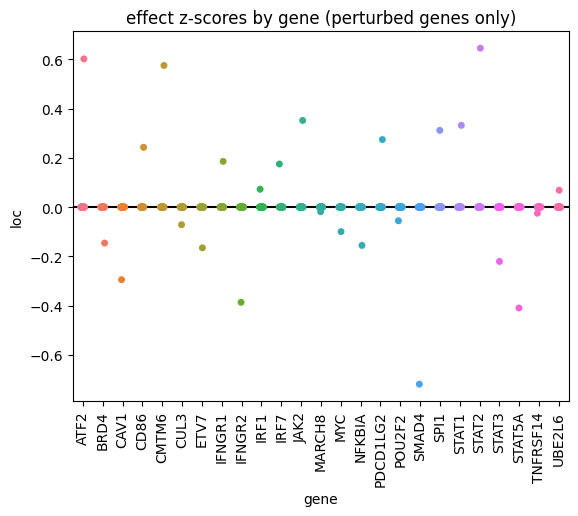

In [47]:
n_plot_genes = 25
sns.stripplot(effects_df.iloc[:, :n_plot_genes])
# sns.stripplot(effects_df[[g for g in plot_genes if g in effects_df.columns]])
#
plt.axhline(0, color="black")
plt.xticks(rotation=90)
plt.ylabel("loc")
plt.title("effect z-scores by gene (perturbed genes only)")
plt.show()

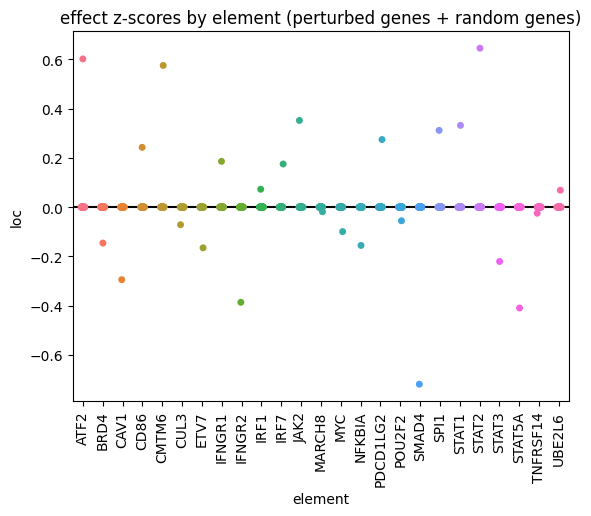

In [48]:
sns.stripplot(effects_df.T, alpha=1)
plt.xticks(rotation=90)
plt.axhline(0, color="black")
plt.ylabel("loc")
plt.xlabel("element")
plt.title("effect z-scores by element (perturbed genes + random genes)")
plt.show()

In [49]:
effects_df.T["CMTM6"].sort_values()

gene
ATF2        0.000000
STAT5A      0.000000
STAT3       0.000000
STAT2       0.000000
STAT1       0.000000
SPI1        0.000000
SMAD4       0.000000
POU2F2      0.000000
PDCD1LG2    0.000000
NFKBIA      0.000000
MYC         0.000000
TNFRSF14    0.000000
MARCH8      0.000000
IRF7        0.000000
IRF1        0.000000
IFNGR2      0.000000
IFNGR1      0.000000
ETV7        0.000000
CUL3        0.000000
CD86        0.000000
CAV1        0.000000
BRD4        0.000000
JAK2        0.000000
UBE2L6      0.000000
CMTM6       0.575085
Name: CMTM6, dtype: float32